# Oxford-IIIT Pet subset: frozen-split EDA

Run this only after `scripts/prepare_oxford_pets.py`. This notebook reads frozen manifests and reports; it does not create or modify a split. No model output is used, and augmentation examples come from **train only**.

In [1]:
from pathlib import Path
import json
import sys
import yaml

# Import PyTorch before pandas/seaborn: in this Windows environment their DLLs
# must not be loaded before PyTorch (otherwise c10.dll raises WinError 1114).
import torch
import torchvision
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from PIL import Image

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'splits').exists())
sys.path.insert(0, str(ROOT))
CONFIG_PATH = ROOT / 'configs' / 'data.yaml'
config = yaml.safe_load(CONFIG_PATH.read_text(encoding='utf-8'))
DATASET_ROOT = (ROOT / config['dataset_root']).resolve()
SPLIT_DIR = (ROOT / config['split_dir']).resolve()
assert DATASET_ROOT.is_dir(), f'Missing local data: {DATASET_ROOT}'
assert (SPLIT_DIR / 'train.csv').is_file(), 'Run preparation first.'
print({'python_executable': sys.executable, 'python': sys.version.split()[0],
       'torch': torch.__version__, 'torchvision': torchvision.__version__,
       'active_split': str(SPLIT_DIR)})


{'python_executable': 'C:\\Users\\Я\\AppData\\Local\\Programs\\Python\\Python311\\python.exe', 'python': '3.11.2', 'torch': '2.13.0+cpu', 'torchvision': '0.28.0+cpu', 'active_split': 'C:\\Users\\Я\\PycharmProjects\\Computer_Vision-project\\splits\\v2'}


In [2]:
mapping = json.loads((SPLIT_DIR / 'class_mapping.json').read_text(encoding='utf-8'))
display(pd.DataFrame(mapping['classes']))
splits = {name: pd.read_csv(SPLIT_DIR / f'{name}.csv') for name in ('train', 'val', 'test')}
all_rows = pd.concat([frame.assign(split=name) for name, frame in splits.items()], ignore_index=True)
all_rows.head()

,label,class_name,official_class_name
0,0,British Shorthair,British_Shorthair
1,1,Russian Blue,Russian_Blue
2,2,Siamese,Siamese
3,3,Birman,Birman
4,4,American Bulldog,american_bulldog
5,5,Pug,pug
6,6,Sphynx,Sphynx
7,7,Maine Coon,Maine_Coon
8,8,Beagle,beagle
9,9,Samoyed,samoyed


,image_id,relative_path,class_name,label,content_hash,split
0,Birman_1,images/Birman_1.jpg,Birman,3,240f04de973f0842b6beda0956bd4bd0a057aed458d192...,train
1,Birman_100,images/Birman_100.jpg,Birman,3,254c2b71ede91a9de5bd13d56cd00d64d71a7cf3bd92cb...,train
2,Birman_102,images/Birman_102.jpg,Birman,3,fa4283b1e9f571b53372c4a84359173c37cce48ee92cef...,train
3,Birman_104,images/Birman_104.jpg,Birman,3,d8af309768146fbfed3cf1c2c0d2254c8768deabeee9d1...,train
4,Birman_106,images/Birman_106.jpg,Birman,3,097c40d59e45cd914eb237ec61371fdeee8361c3026fc5...,train


## Class sizes before and after exact-duplicate cleanup

,before_exact_dedup,after_exact_dedup
American Bulldog,200,200
Beagle,200,200
Birman,200,200
British Shorthair,200,200
Maine Coon,200,200
Pug,200,200
Russian Blue,200,200
Samoyed,200,200
Siamese,199,199
Sphynx,200,200


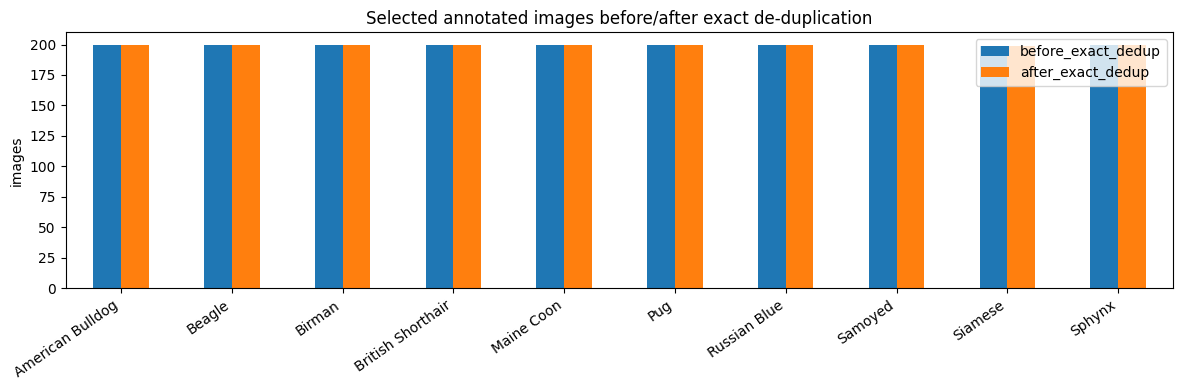

In [3]:
integrity = json.loads((SPLIT_DIR / 'integrity_report.json').read_text(encoding='utf-8'))
counts = pd.DataFrame({'before_exact_dedup': integrity['counts_before_exact_dedup'],
                       'after_exact_dedup': integrity['counts_after_exact_dedup']}).fillna(0).astype(int)
display(counts)
counts.plot.bar(figsize=(12, 4), ylabel='images', title='Selected annotated images before/after exact de-duplication');
plt.xticks(rotation=35, ha='right'); plt.tight_layout()

## Frozen split distribution and leakage checks

split,train,val,test
class_name,,,
American Bulldog,140,30,30
Beagle,140,30,30
Birman,140,30,30
British Shorthair,140,30,30
Maine Coon,140,30,30
Pug,140,30,30
Russian Blue,140,30,30
Samoyed,140,30,30
Siamese,139,30,30


OK: train/val/test do not intersect by image_id, relative_path, or content_hash.


train    1399
val       300
test      300
Name: images, dtype: int64

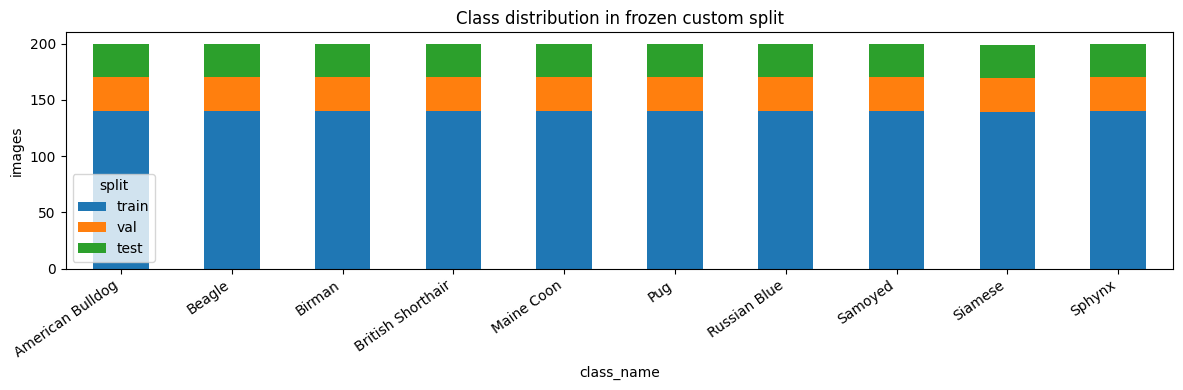

In [4]:
distribution = pd.crosstab(all_rows['class_name'], all_rows['split']).reindex(columns=['train', 'val', 'test'], fill_value=0)
display(distribution)
distribution.plot.bar(stacked=True, figsize=(12, 4), ylabel='images', title='Class distribution in frozen custom split');
plt.xticks(rotation=35, ha='right'); plt.tight_layout()

for field in ('image_id', 'relative_path', 'content_hash'):
    sets = {name: set(frame[field]) for name, frame in splits.items()}
    assert not (sets['train'] & sets['val'] or sets['train'] & sets['test'] or sets['val'] & sets['test']), field
print('OK: train/val/test do not intersect by image_id, relative_path, or content_hash.')
display(pd.Series({name: len(frame) for name, frame in splits.items()}, name='images'))

## Integrity and duplicate reports

Near-duplicate entries are candidates for manual review only; they are not removed based on perceptual-hash distance.

In [5]:
exact = json.loads((SPLIT_DIR / 'exact_duplicates.json').read_text(encoding='utf-8'))
near = json.loads((SPLIT_DIR / 'near_duplicate_candidates.json').read_text(encoding='utf-8'))
print({'annotation_candidates': integrity['annotation_candidates'], 'valid_decoded': integrity['valid_decoded'],
       'retained_after_exact_dedup': integrity['retained_after_exact_dedup'],
       'excluded': len(integrity['excluded']), 'exact_duplicate_groups': len(exact['groups']),
       'near_duplicate_candidates': len(near['candidates'])})
display(pd.DataFrame(integrity['excluded']))
display(pd.DataFrame(exact['groups']))
display(pd.DataFrame(near['candidates']).head(50))

{'annotation_candidates': 1999, 'valid_decoded': 1999, 'retained_after_exact_dedup': 1999, 'excluded': 0, 'exact_duplicate_groups': 0, 'near_duplicate_candidates': 91}


""


""


,hamming_distance,image_id_a,image_id_b,same_class
0,5,Birman_120,Russian_Blue_226,False
1,5,Birman_120,Siamese_233,False
2,5,Birman_120,beagle_56,False
3,5,Birman_133,Siamese_151,False
4,5,Birman_136,Russian_Blue_166,False
5,5,Birman_140,samoyed_83,False
6,5,Birman_147,Sphynx_172,False
7,5,Birman_196,beagle_7,False
8,0,Birman_199,Birman_25,True
9,5,Birman_6,beagle_7,False


## Human review status for perceptual-hash candidates

This is a data-integrity workflow only. The decisions below must not be used for preprocessing, split, class, hyperparameter, or model-condition decisions. `uncertain` remains open for local visual inspection.

In [6]:
review_path = ROOT / 'splits' / 'near_duplicate_review.csv'
status_path = ROOT / 'splits' / 'near_duplicate_review_status.json'
assert review_path.is_file() and status_path.is_file(), 'Build the queue: py -3 scripts/review_near_duplicates.py'
review = pd.read_csv(review_path)
review_status = json.loads(status_path.read_text(encoding='utf-8'))
display(review['decision'].value_counts(dropna=False).rename_axis('decision').to_frame('pairs'))
display(review[review['decision'].isin(['duplicate', 'near-duplicate'])])
crossings = pd.DataFrame(review_status['confirmed_cross_split_pairs'])
display(crossings if not crossings.empty else pd.DataFrame({'status': ['No confirmed cross-split pairs.']}))
unresolved_crossings = pd.DataFrame(review_status['unresolved_cross_split_candidates'])
print(f'Unresolved cross-split candidates requiring visual review: {len(unresolved_crossings)}')
confirmed_groups = json.loads((SPLIT_DIR / 'confirmed_groups_applied.json').read_text(encoding='utf-8'))
group_splits = []
id_to_split = all_rows.set_index('image_id')['split'].to_dict()
for group in confirmed_groups['groups']:
    assigned_splits = sorted({id_to_split[image_id] for image_id in group})
    group_splits.append({'confirmed_group': ', '.join(group), 'splits': ', '.join(assigned_splits)})
assert all(len(item['splits'].split(', ')) == 1 for item in group_splits), 'A confirmed group crosses splits.'
display(pd.DataFrame(group_splits))
print('OK: every confirmed duplicate or near-duplicate group is wholly within one split.')
print('For local side-by-side inspection, open:', ROOT / 'splits' / 'near_duplicate_review.html')

,pairs
decision,
different images,84
near-duplicate,4
duplicate,3


,pair_id,image_id_a,class_name_a,split_a,relative_path_a,image_id_b,class_name_b,split_b,relative_path_b,hamming_distance,same_class,decision,review_notes
8,Birman_199__Birman_25,Birman_199,Birman,train,images/Birman_199.jpg,Birman_25,Birman,test,images/Birman_25.jpg,0,True,duplicate,NaN
20,British_Shorthair_160__British_Shorthair_278,British_Shorthair_160,British Shorthair,train,images/British_Shorthair_160.jpg,British_Shorthair_278,British Shorthair,train,images/British_Shorthair_278.jpg,0,True,duplicate,NaN
25,British_Shorthair_186__British_Shorthair_271,British_Shorthair_186,British Shorthair,val,images/British_Shorthair_186.jpg,British_Shorthair_271,British Shorthair,train,images/British_Shorthair_271.jpg,0,True,duplicate,NaN
32,British_Shorthair_57__British_Shorthair_58,British_Shorthair_57,British Shorthair,train,images/British_Shorthair_57.jpg,British_Shorthair_58,British Shorthair,train,images/British_Shorthair_58.jpg,4,True,near-duplicate,NaN
87,samoyed_188__samoyed_189,samoyed_188,Samoyed,train,images/samoyed_188.jpg,samoyed_189,Samoyed,train,images/samoyed_189.jpg,5,True,near-duplicate,NaN
88,samoyed_188__samoyed_194,samoyed_188,Samoyed,train,images/samoyed_188.jpg,samoyed_194,Samoyed,train,images/samoyed_194.jpg,2,True,near-duplicate,NaN
90,samoyed_23__samoyed_24,samoyed_23,Samoyed,train,images/samoyed_23.jpg,samoyed_24,Samoyed,train,images/samoyed_24.jpg,1,True,near-duplicate,NaN


,pair_id,image_id_a,class_name_a,split_a,relative_path_a,image_id_b,class_name_b,split_b,relative_path_b,hamming_distance,same_class,decision,review_notes
0,Birman_199__Birman_25,Birman_199,Birman,train,images/Birman_199.jpg,Birman_25,Birman,test,images/Birman_25.jpg,0,True,duplicate,
1,British_Shorthair_186__British_Shorthair_271,British_Shorthair_186,British Shorthair,val,images/British_Shorthair_186.jpg,British_Shorthair_271,British Shorthair,train,images/British_Shorthair_271.jpg,0,True,duplicate,


Unresolved cross-split candidates requiring visual review: 0


,confirmed_group,splits
0,"Birman_199, Birman_25",train
1,"British_Shorthair_160, British_Shorthair_278",train
2,"British_Shorthair_186, British_Shorthair_271",test
3,"British_Shorthair_57, British_Shorthair_58",train
4,"samoyed_188, samoyed_189, samoyed_194",train
5,"samoyed_23, samoyed_24",val


OK: every confirmed duplicate or near-duplicate group is wholly within one split.
For local side-by-side inspection, open: C:\Users\Я\PycharmProjects\Computer_Vision-project\splits\near_duplicate_review.html


## Image dimensions and aspect ratios

,width,height,aspect_ratio
count,1999.000000,1999.000000,1999.000000
mean,437.775888,393.201101,1.172708
std,92.371117,90.781374,0.342115
min,161.000000,150.000000,0.558000
25%,350.000000,333.000000,0.750000
50%,500.000000,375.000000,1.333333
75%,500.000000,500.000000,1.497006
max,1200.000000,901.000000,2.183406


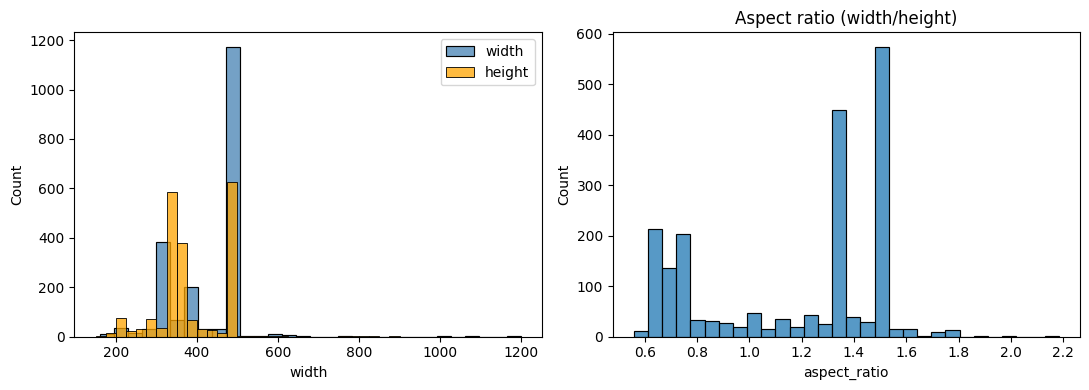

In [7]:
def dimensions(relative_path):
    with Image.open(DATASET_ROOT / relative_path) as image:
        return image.size

sizes = all_rows['relative_path'].map(dimensions)
all_rows[['width', 'height']] = pd.DataFrame(sizes.tolist(), index=all_rows.index)
all_rows['aspect_ratio'] = all_rows['width'] / all_rows['height']
display(all_rows[['width', 'height', 'aspect_ratio']].describe())
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(all_rows['width'], bins=30, ax=axes[0], label='width', color='steelblue')
sns.histplot(all_rows['height'], bins=30, ax=axes[0], label='height', color='orange'); axes[0].legend()
sns.histplot(all_rows['aspect_ratio'], bins=30, ax=axes[1]); axes[1].set_title('Aspect ratio (width/height)')
plt.tight_layout()

## Train-only original and augmentation examples

Each row shows one original full RGB training photo and one independently augmented view for every class. No validation or test image is displayed here.

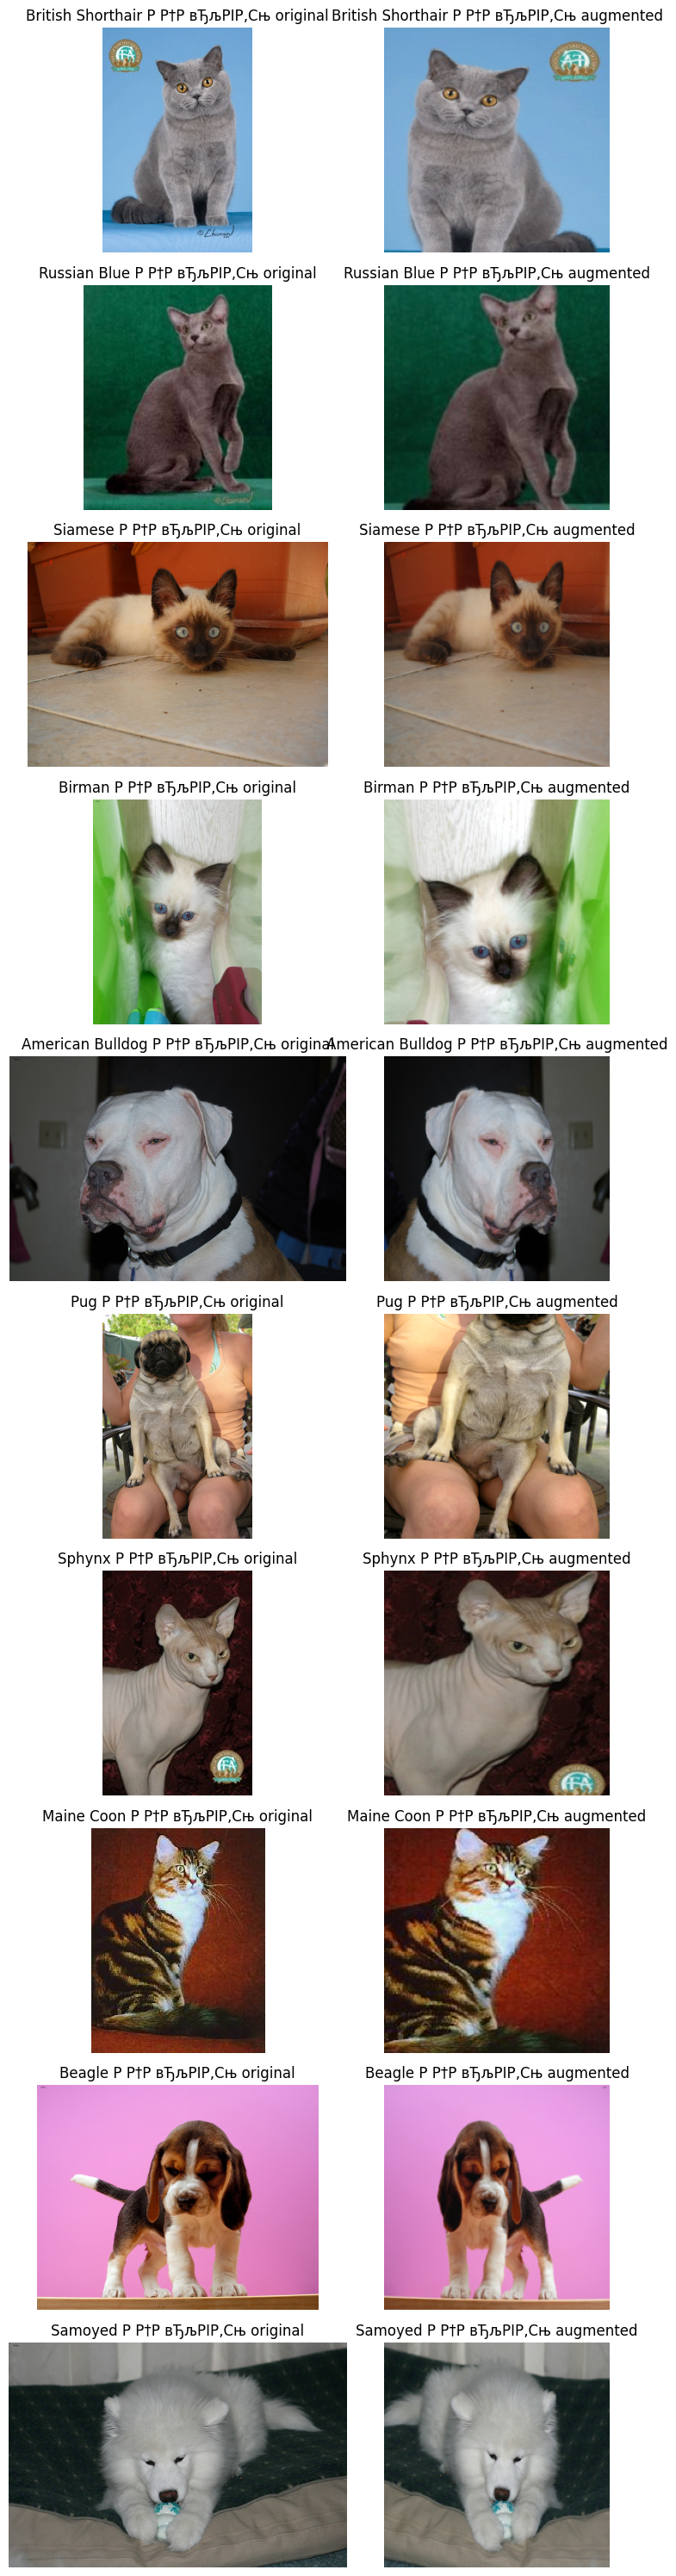

In [8]:
import torch
from src.dataset import PetManifestDataset, _train_transform

train_dataset = PetManifestDataset(DATASET_ROOT, SPLIT_DIR / 'train.csv', SPLIT_DIR / 'class_mapping.json', _train_transform())
mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
index_by_id = {row['image_id']: index for index, row in enumerate(train_dataset.rows)}
examples = splits['train'].sort_values(['label', 'image_id']).groupby('label', as_index=False).first()
fig, axes = plt.subplots(len(examples), 2, figsize=(8, 3 * len(examples)))
for axis_pair, (_, row) in zip(axes, examples.iterrows()):
    with Image.open(DATASET_ROOT / row['relative_path']) as source:
        original = source.convert('RGB')
    axis_pair[0].imshow(original)
    axis_pair[0].set_title(f"{row['class_name']} Р Р†Р вЂљРІР‚Сњ original")
    tensor, label = train_dataset[index_by_id[row['image_id']]]
    augmented = (tensor * std + mean).clamp(0, 1).permute(1, 2, 0)
    axis_pair[1].imshow(augmented)
    axis_pair[1].set_title(f"{train_dataset.mapping[label]} Р Р†Р вЂљРІР‚Сњ augmented")
    for axis in axis_pair:
        axis.axis('off')
plt.tight_layout()